In [1]:
import sys

import qiskit
import qiskit_aer
import qiskit_ibm_runtime

print(f"Python: {sys.version.split()[0]}")
print(f"qiskit: {qiskit.__version__}")
print(f"qiskit-aer: {qiskit_aer.__version__}")
print(f"qiskit-ibm-runtime: {qiskit_ibm_runtime.__version__}")

Python: 3.11.2
qiskit: 2.5.0
qiskit-aer: 0.17.2
qiskit-ibm-runtime: 0.48.0


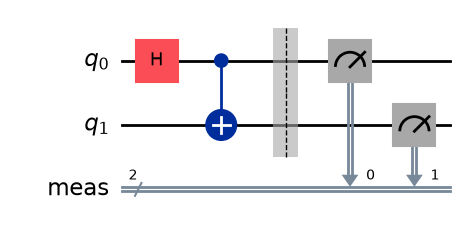

In [2]:
bell = qiskit.QuantumCircuit(2)
bell.h(0)
bell.cx(0,1)

bell.measure_all()
bell.draw("mpl")

In [3]:
def run_circuit_and_get_counts(circuit, backend, shots=1000):
    """
    Runs a quantum circuit on a specified backend and returns the measurement counts.

    Args:
        circuit (QuantumCircuit): The quantum circuit to run.
        backend: The Qiskit backend (real device or simulator).
        shots (int): The number of shots to run the circuit.

    Returns:
        dict: A dictionary of measurement counts.
    """
    print("hiya")
    pm = qiskit.transpiler.generate_preset_pass_manager(backend=backend, optimization_level=1)
    print("let's get started")
    isa_circuit = pm.run(circuit)
    print("first here")
    sampler = qiskit_ibm_runtime.Sampler(mode=backend)
    print("and now here")
    job = sampler.run([isa_circuit], shots=shots)
    print("got result!")
    result = job.result()
    print(f"here it is: {result}") 
    
    return result[0].data.meas.get_counts()

In [4]:
import yaml

token = ''
with open('secrets.yaml') as f:
    cfg = yaml.load(f, Loader=yaml.FullLoader)
    token = cfg['token']
    
qiskit_ibm_runtime.QiskitRuntimeService.save_account(channel='ibm_quantum_platform', token=token, overwrite=True, set_as_default=True)
service = qiskit_ibm_runtime.QiskitRuntimeService(channel='ibm_quantum_platform')

# load saved credentials
service = qiskit_ibm_runtime.QiskitRuntimeService()

# use the least busy backend, or uncomment the loading of a specific backend like "ibm_fez"
backend = service.least_busy(operational=True, simulator=False, min_num_qubits=127)
# backend = serivce.backend("ibm_fez")
print(backend.name)

qiskit_runtime_service.__init__:WARNING:2026-07-16 01:08:19,838: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.
qiskit_runtime_service.__init__:WARNING:2026-07-16 01:08:21,537: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default insta

ibm_kingston


In [5]:
print("let's jam")
counts = run_circuit_and_get_counts(bell, backend, shots=1000)
print("that was fun")
plot_histogram(counts)
print('good work')

let's jam
hiya
let's get started
first here
and now here
got result!
here it is: PrimitiveResult([SamplerPubResult(data=DataBin(meas=BitArray(<shape=(), num_shots=1000, num_bits=2>)), metadata={'circuit_metadata': {}})], metadata={'execution': {'execution_spans': ExecutionSpans([DoubleSliceSpan(<start='2026-07-16 05:09:57', stop='2026-07-16 05:09:58', size=1000>)])}, 'version': 2})
that was fun


NameError: name 'plot_histogram' is not defined

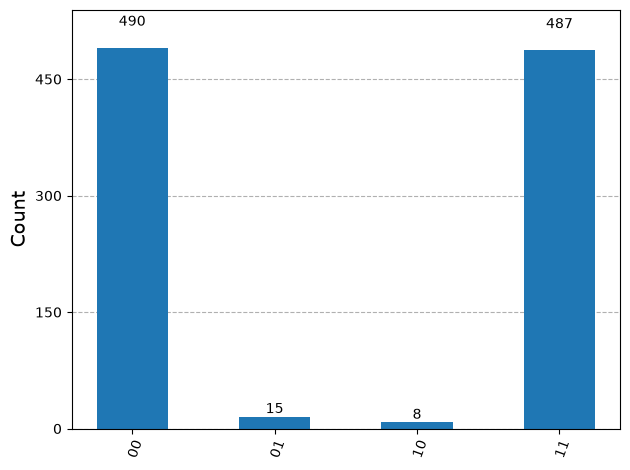

In [6]:
qiskit.visualization.plot_histogram(counts)